#### Import

In [1]:
import sys
sys.path.insert(0, '..')
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import (
    compute_class_weights, train_with_early_stopping, print_test_evaluation
)
from src.gnn.visualization import plot_learning_curves

#### Seed

In [2]:
set_seed(42)

#### Load data

In [3]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt')

Device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Multi-seed

In [4]:
import numpy as np
import torch
from src.gnn.seed import set_seed
from src.gnn.training import compute_class_weights, train_with_early_stopping, evaluate
seeds = [42, 0, 123]
results = []
for seed in seeds:
    print(f"\n{'='*40}\nRUNNING GCN WITH SEED {seed}\n{'='*40}")
    
    set_seed(seed)

    class GCN(torch.nn.Module):
        def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)
            self.dropout = dropout

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = self.conv2(x, edge_index)
            return x
    
    model = GCN(
        in_channels=data.x.shape[1],
        hidden_channels=64,
        out_channels=2,
        dropout=0.5,
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    # 4. Huấn luyện (Early Stopping)
    save_path = f'../saved_models/gcn_best_seed_{seed}.pt'
    history = train_with_early_stopping(
        model, data, optimizer, criterion,
        save_path=save_path,
        num_epochs=200,
        patience=20,
        monitor_metric='f1_ill',
    )
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    
    print(f"\n--- Test Results for SEED {seed} ---")
    print(f"  F1(illicit): {test_metrics['f1_ill']:.4f}")
    print(f"  Precision  : {test_metrics['precision_ill']:.4f}")
    print(f"  Recall     : {test_metrics['recall_ill']:.4f}")
    print(f"  AUC-PR     : {test_metrics['auc_pr']:.4f}\n")
    
    results.append({
        'seed': seed,
        'f1_ill': test_metrics['f1_ill'],
        'precision': test_metrics['precision_ill'],
        'recall': test_metrics['recall_ill'],
        'auc_pr': test_metrics['auc_pr']
    })

f1_ill_list = [res['f1_ill'] for res in results]
precision_list = [res['precision'] for res in results]
recall_list = [res['recall'] for res in results]
auc_pr_list = [res['auc_pr'] for res in results]
print(f"\n{'='*40}\nFINAL GCN MULTI-SEED RESULTS\n{'='*40}")
print(f"F1(illicit): {np.mean(f1_ill_list):.4f} ± {np.std(f1_ill_list):.4f}")
print(f"Precision  : {np.mean(precision_list):.4f} ± {np.std(precision_list):.4f}")
print(f"Recall     : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"AUC-PR     : {np.mean(auc_pr_list):.4f} ± {np.std(auc_pr_list):.4f}")


RUNNING GCN WITH SEED 42
Class weights: licit=1.00, illicit=2.86
Epoch 001: Train Loss=0.8818, Train F1=0.4778, Val F1=0.3818, Gap=0.0960
Epoch 002: Train Loss=0.4893, Train F1=0.5769, Val F1=0.5125, Gap=0.0644
Epoch 003: Train Loss=0.3745, Train F1=0.6233, Val F1=0.5269, Gap=0.0963
Epoch 004: Train Loss=0.3314, Train F1=0.6426, Val F1=0.5131, Gap=0.1294
Epoch 005: Train Loss=0.3024, Train F1=0.6566, Val F1=0.5117, Gap=0.1449
Epoch 006: Train Loss=0.2961, Train F1=0.6724, Val F1=0.5303, Gap=0.1421
Epoch 007: Train Loss=0.2737, Train F1=0.6974, Val F1=0.5542, Gap=0.1432
Epoch 008: Train Loss=0.2679, Train F1=0.7126, Val F1=0.5664, Gap=0.1462
Epoch 009: Train Loss=0.2642, Train F1=0.7220, Val F1=0.5697, Gap=0.1523
Epoch 010: Train Loss=0.2522, Train F1=0.7291, Val F1=0.5799, Gap=0.1492
Epoch 011: Train Loss=0.2442, Train F1=0.7273, Val F1=0.5848, Gap=0.1425
Epoch 012: Train Loss=0.2378, Train F1=0.7261, Val F1=0.5865, Gap=0.1396
Epoch 013: Train Loss=0.2336, Train F1=0.7291, Val F1=0.59

#### Define model

2-layer Graph Convolutional Network (GCN) structure:

In [13]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(
    in_channels=data.x.shape[1],
    hidden_channels=64,
    out_channels=2,
    dropout=0.5,
).to(device)

print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

GCN(
  (conv1): GCNConv(165, 64)
  (conv2): GCNConv(64, 2)
)
Number of parameters: 10,754


#### Optimizer, loss, class weights

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
weight = compute_class_weights(data, device)
criterion = torch.nn.CrossEntropyLoss(weight=weight)

Class weights: licit=1.00, illicit=2.86


#### Training loop

In [15]:
history = train_with_early_stopping(
    model, data, optimizer, criterion,
    save_path='../saved_models/gcn_best.pt',
    num_epochs=200,
    patience=20,
)

Epoch 001: Train Loss=0.8818, Train F1=0.4778, Val F1=0.3818, Gap=0.0960
Epoch 002: Train Loss=0.4893, Train F1=0.5769, Val F1=0.5125, Gap=0.0644
Epoch 003: Train Loss=0.3745, Train F1=0.6233, Val F1=0.5269, Gap=0.0963
Epoch 004: Train Loss=0.3314, Train F1=0.6426, Val F1=0.5131, Gap=0.1294
Epoch 005: Train Loss=0.3024, Train F1=0.6566, Val F1=0.5117, Gap=0.1449
Epoch 006: Train Loss=0.2961, Train F1=0.6724, Val F1=0.5303, Gap=0.1421
Epoch 007: Train Loss=0.2737, Train F1=0.6974, Val F1=0.5542, Gap=0.1432
Epoch 008: Train Loss=0.2679, Train F1=0.7126, Val F1=0.5664, Gap=0.1462
Epoch 009: Train Loss=0.2642, Train F1=0.7220, Val F1=0.5697, Gap=0.1523
Epoch 010: Train Loss=0.2522, Train F1=0.7291, Val F1=0.5799, Gap=0.1492
Epoch 011: Train Loss=0.2442, Train F1=0.7273, Val F1=0.5848, Gap=0.1425
Epoch 012: Train Loss=0.2378, Train F1=0.7261, Val F1=0.5865, Gap=0.1396
Epoch 013: Train Loss=0.2336, Train F1=0.7291, Val F1=0.5929, Gap=0.1362
Epoch 014: Train Loss=0.2403, Train F1=0.7361, Val 

#### Learning curve

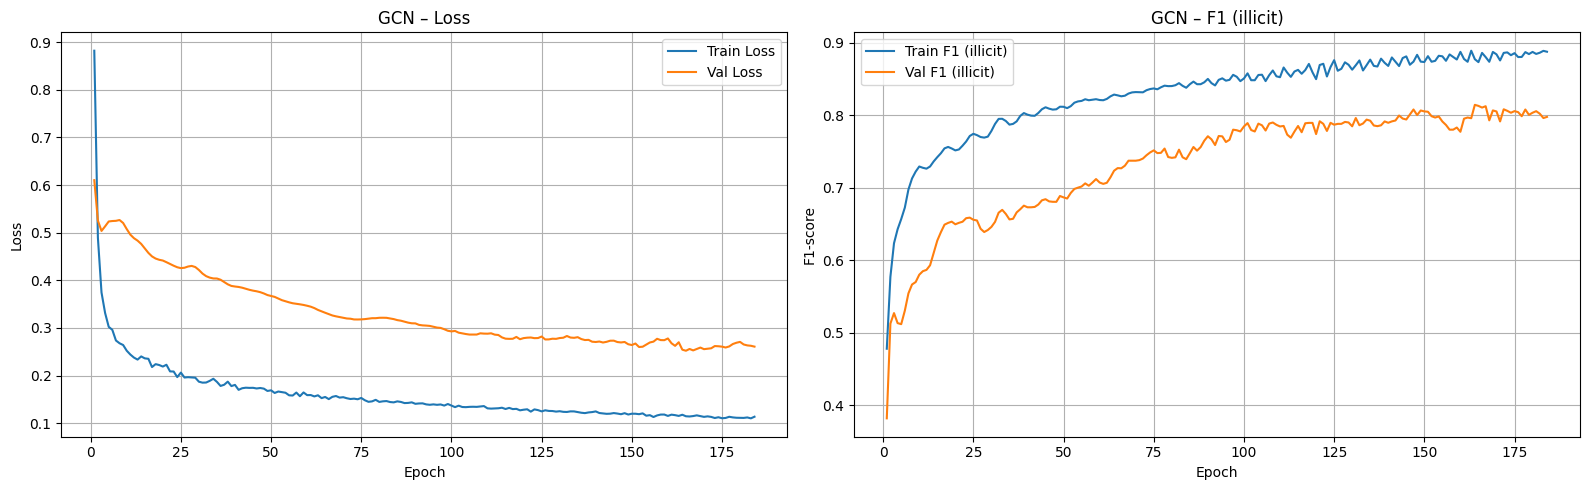

In [16]:
plot_learning_curves(history, model_name="GCN")

#### Test evaluation

In [18]:
model.load_state_dict(torch.load('../saved_models/gcn_best.pt'))
print_test_evaluation(model, data, criterion, label="GCN Test")

 GCN Test Set Evaluation
  Loss          : 0.3458
  Accuracy      : 0.9403
  Precision(ill): 0.5386
  Recall(ill)   : 0.5669
  F1(illicit)   : 0.5524
  F1(macro)     : 0.7602
  AUC-PR        : 0.5220

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9698    0.9663    0.9680     15587
 Illicit (1)     0.5386    0.5669    0.5524      1083

    accuracy                         0.9403     16670
   macro avg     0.7542    0.7666    0.7602     16670
weighted avg     0.9418    0.9403    0.9410     16670

Confusion Matrix:
[[15061   526]
 [  469   614]]
